<a href="https://colab.research.google.com/github/pinballsurgeon/deluxo_adjacency/blob/main/quantum_precursurs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prigogine dissipative structures

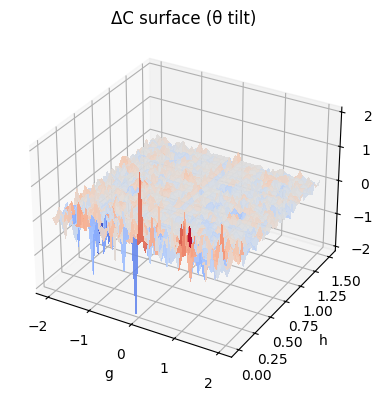

In [1]:
# cirq install
!pip install -q cirq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 77.9 MB/s eta 0:00:00


# Jon Wheeler's delayed choice

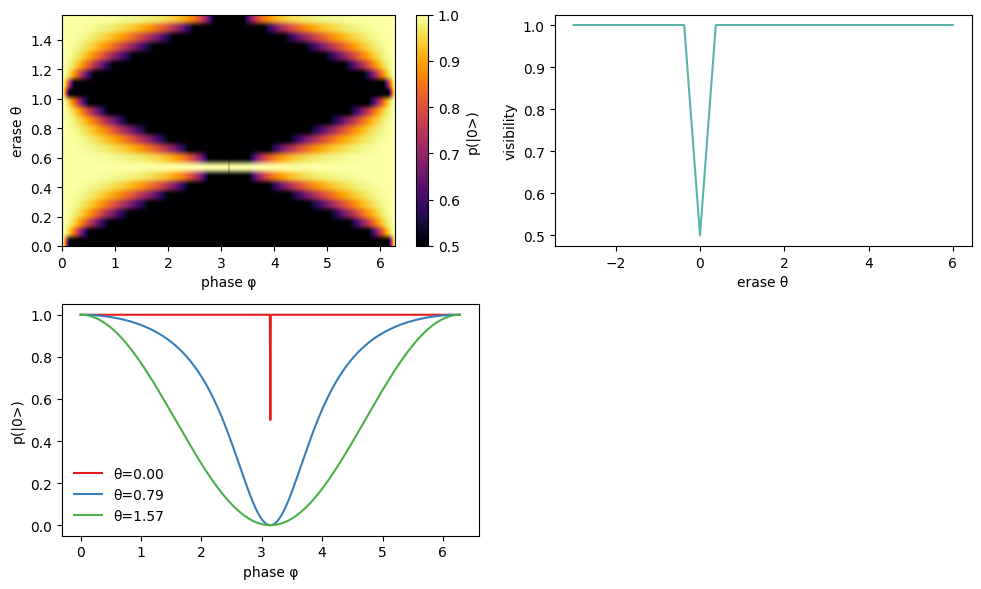

In [2]:
# wheeler quantum eraser
import numpy as np, cirq, matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-dark-palette')

a, b = cirq.LineQubit.range(2)  # path qubit, ancilla marker

# conditional probability p(a=0 | b in |+>)
def p0(theta, phi):
    c = cirq.Circuit(
        cirq.H(a),
        cirq.CNOT(a, b),              # which‑path mark
        cirq.Z(a) ** (phi / np.pi),   # phase between paths
        cirq.ry(theta)(b),            # eraser rotation
        cirq.CNOT(b, a)               # erase / recombine
    )
    rho = cirq.DensityMatrixSimulator().simulate(c).final_density_matrix
    P_plus = np.array([[0.5, 0.5], [0.5, 0.5]])          # |+><+|
    proj = np.kron(np.eye(2), P_plus)
    rho_post = proj @ rho @ proj
    p_plus = np.real(np.trace(rho_post))
    if p_plus < 1e-12:
        return 0.5
    rho_cond = rho_post / p_plus
    P0 = np.kron(np.array([[1, 0], [0, 0]]), np.eye(2))
    return float(np.real(np.trace(rho_cond @ P0)))

ths = np.linspace(-3, 6, 25)          # erase angle θ
phis = np.linspace(0, 2*np.pi, 801)   # interferometer phase φ
P = np.zeros((len(ths), len(phis)))
for i, th in enumerate(ths):
    for j, ph in enumerate(phis):
        P[i, j] = p0(th, ph)

vis = P.max(axis=1) - P.min(axis=1)

fig, axs = plt.subplots(2, 2, figsize=(10, 6))
# heat‑map of interference fringes
hm = axs[0, 0].imshow(P, aspect='auto', origin='lower',
                      extent=[0, 2 * np.pi, 0, np.pi / 2],
                      cmap='inferno', vmin=0.5, vmax=1.0)
axs[0, 0].set(xlabel='phase φ', ylabel='erase θ')
plt.colorbar(hm, ax=axs[0, 0], label='p(|0>)')
# visibility curve
axs[0, 1].plot(ths, vis, color='#5ab4ac')
axs[0, 1].set(xlabel='erase θ', ylabel='visibility')
# fringe slices
for th_val, col in [(0, '#e41a1c'), (np.pi/4, '#377eb8'), (np.pi/2, '#4daf4a')]:
    curve = [p0(th_val, ph) for ph in phis]
    axs[1, 0].plot(phis, curve, label=f'θ={th_val:.2f}', color=col)
axs[1, 0].set(xlabel='phase φ', ylabel='p(|0>)'); axs[1, 0].legend(frameon=False)
axs[1, 1].axis('off')
plt.tight_layout(); plt.show()


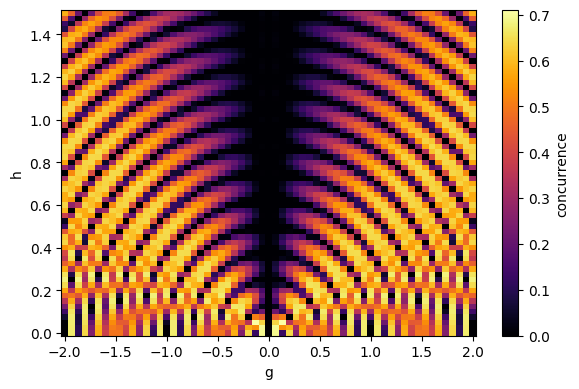

In [3]:
# resonance landscape sweep g,h  – minimal
import numpy as np, matplotlib.pyplot as plt, cirq

# grid
gs=np.linspace(-2,2,61)
hs=np.linspace(0,1.5,61)
gamma=0.02; theta=np.pi/4

# pauli
I=np.eye(2); X=np.array([[0,1],[1,0]]); Z=np.array([[1,0],[0,-1]])
Y=np.array([[0,-1j],[1j,0]])

# hamiltonian and jump
def H(g,h):
    return g*np.kron(Z,Z)+h*(np.kron(X,I)+np.kron(I,X))

def Lk():
    return np.sqrt(gamma)*(np.cos(theta)*np.kron(Z,I)+np.sin(theta)*np.kron(X,I))

L=Lk()

# concurrence helper
S=np.kron(Y,Y)

def concurrence(r):
    w=np.sort(np.real(np.linalg.eigvals(r@S@r.conj()@S)))[::-1]
    lam=np.sqrt(np.clip(w,0,None))
    return max(0,lam[0]-lam[1]-lam[2]-lam[3])

# initial |+>⊗|+>
plus=np.array([1,1])/np.sqrt(2)
rho0=np.kron(np.outer(plus,plus.conj()),np.outer(plus,plus.conj())).astype(complex)

from scipy.integrate import solve_ivp
T=4*np.pi
Cmat=np.zeros((len(hs),len(gs)))
for i,h in enumerate(hs):
    for j,g in enumerate(gs):
        def rhs(_,v):
            r=v.reshape(4,4)
            d=-1j*(H(g,h)@r-r@H(g,h))
            d+=L@r@L.conj().T-0.5*(L.conj().T@L@r+r@L.conj().T@L)
            return d.reshape(-1)
        sol=solve_ivp(rhs,(0,T),rho0.reshape(-1),t_eval=[T],rtol=3e-5,atol=1e-7)
        Cmat[i,j]=concurrence(sol.y[:,-1].reshape(4,4))

plt.figure(figsize=(6,4))
plt.pcolormesh(gs,hs,Cmat,cmap='inferno',shading='auto')
plt.xlabel('g');plt.ylabel('h');plt.colorbar(label='concurrence')
plt.tight_layout();plt.show()


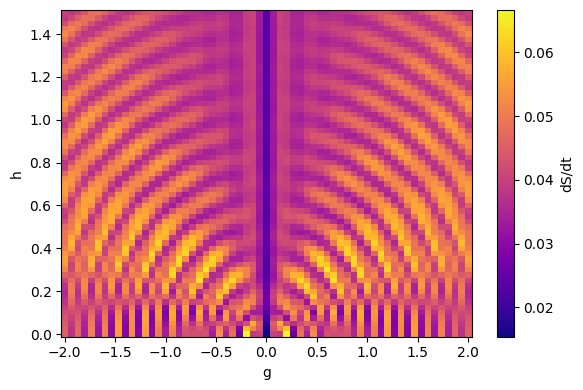

In [4]:
# entropy rate landscape – minimal
gamma=0.02;theta=np.pi/4
Y=np.array([[0,-1j],[1j,0]])

def von_entropy(r):
    ev=np.clip(np.real(np.linalg.eigvalsh(r)),1e-12,1)
    return -np.sum(ev*np.log2(ev))

dS=np.zeros_like(Cmat)
for i,h in enumerate(hs):
    for j,g in enumerate(gs):
        def rhs(_,v):
            r=v.reshape(4,4)
            d=-1j*(H(g,h)@r-r@H(g,h))
            d+=L@r@L.conj().T-0.5*(L.conj().T@L@r+r@L.conj().T@L)
            return d.reshape(-1)
        sol=solve_ivp(rhs,(0,T),rho0.reshape(-1),t_eval=[T-0.5,T],rtol=3e-5,atol=1e-7)
        r1,r2=sol.y[:,0].reshape(4,4),sol.y[:,-1].reshape(4,4)
        dS[i,j]=(von_entropy(r2)-von_entropy(r1))/0.5

plt.figure(figsize=(6,4))
plt.pcolormesh(gs,hs,dS,cmap='plasma',shading='auto')
plt.xlabel('g');plt.ylabel('h');plt.colorbar(label='dS/dt')
plt.tight_layout();plt.show()


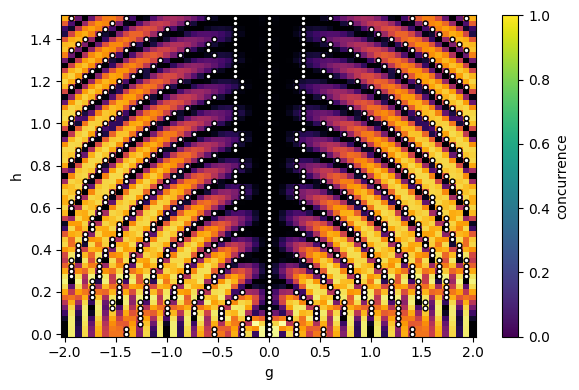

In [5]:
# Σ overlay on concurrence – minimal
from scipy.signal import argrelextrema

# find local minima of dS along g axis
dS_arr=dS.copy();
mins=[]
for i in range(len(hs)):
    inds=argrelextrema(dS_arr[i],np.less,order=2)[0]
    for j in inds:
        mins.append((gs[j],hs[i]))
mins=np.array(mins)

plt.figure(figsize=(6,4))
plt.pcolormesh(gs,hs,Cmat,cmap='inferno',shading='auto')
if mins.size:
    plt.scatter(mins[:,0],mins[:,1],s=12,c='white',edgecolor='k')
plt.xlabel('g');plt.ylabel('h');plt.colorbar(label='concurrence')
plt.tight_layout();plt.show()


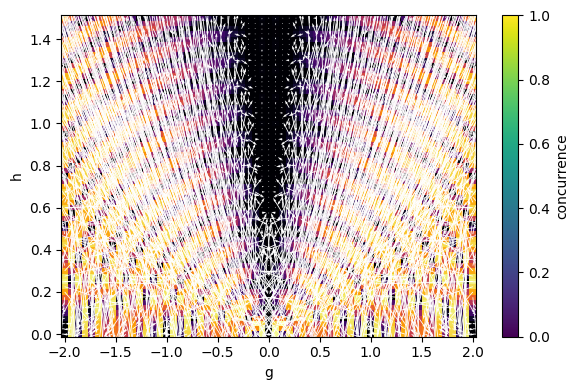

In [6]:
# gradient flow arrows on concurrence – minimal
Gy,Gx=np.gradient(Cmat,hs[1]-hs[0],gs[1]-gs[0])
plt.figure(figsize=(6,4))
plt.pcolormesh(gs,hs,Cmat,cmap='inferno',shading='auto')
plt.quiver(gs,hs,-Gx,-Gy,color='white',scale=40,width=0.002)
plt.xlabel('g');plt.ylabel('h');plt.colorbar(label='concurrence')
plt.tight_layout();plt.show()


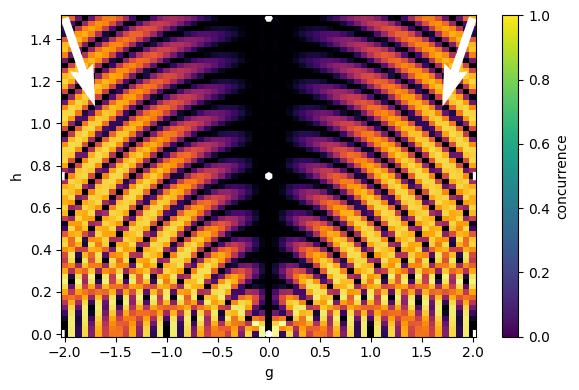

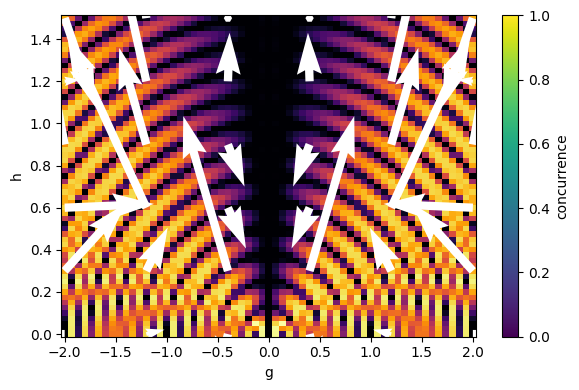

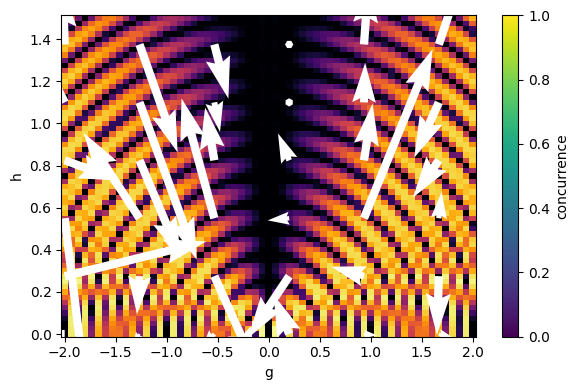

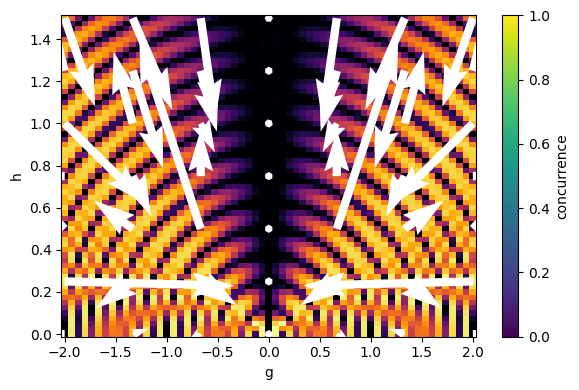

In [7]:
# coarse gradient flow – major trends only
step=30
Gy,Gx=np.gradient(Cmat,hs[1]-hs[0],gs[1]-gs[0])
sub_x=gs[::step]
sub_y=hs[::step]
sub_Gx=-Gx[::step,::step]
sub_Gy=-Gy[::step,::step]
plt.figure(figsize=(6,4))
plt.pcolormesh(gs,hs,Cmat,cmap='inferno',shading='auto')
plt.quiver(sub_x,sub_y,sub_Gx,sub_Gy,color='white',scale=25,width=0.02)
plt.xlabel('g');plt.ylabel('h');plt.colorbar(label='concurrence')
plt.tight_layout();plt.show()


# coarse gradient flow – major trends only
step=12
Gy,Gx=np.gradient(Cmat,hs[1]-hs[0],gs[1]-gs[0])
sub_x=gs[::step]
sub_y=hs[::step]
sub_Gx=-Gx[::step,::step]
sub_Gy=-Gy[::step,::step]
plt.figure(figsize=(6,4))
plt.pcolormesh(gs,hs,Cmat,cmap='inferno',shading='auto')
plt.quiver(sub_x,sub_y,sub_Gx,sub_Gy,color='white',scale=25,width=0.02)
plt.xlabel('g');plt.ylabel('h');plt.colorbar(label='concurrence')
plt.tight_layout();plt.show()


# coarse gradient flow – major trends only
step=11
Gy,Gx=np.gradient(Cmat,hs[1]-hs[0],gs[1]-gs[0])
sub_x=gs[::step]
sub_y=hs[::step]
sub_Gx=-Gx[::step,::step]
sub_Gy=-Gy[::step,::step]
plt.figure(figsize=(6,4))
plt.pcolormesh(gs,hs,Cmat,cmap='inferno',shading='auto')
plt.quiver(sub_x,sub_y,sub_Gx,sub_Gy,color='white',scale=25,width=0.02)
plt.xlabel('g');plt.ylabel('h');plt.colorbar(label='concurrence')
plt.tight_layout();plt.show()


# coarse gradient flow – major trends only
step=10
Gy,Gx=np.gradient(Cmat,hs[1]-hs[0],gs[1]-gs[0])
sub_x=gs[::step]
sub_y=hs[::step]
sub_Gx=-Gx[::step,::step]
sub_Gy=-Gy[::step,::step]
plt.figure(figsize=(6,4))
plt.pcolormesh(gs,hs,Cmat,cmap='inferno',shading='auto')
plt.quiver(sub_x,sub_y,sub_Gx,sub_Gy,color='white',scale=25,width=0.02)
plt.xlabel('g');plt.ylabel('h');plt.colorbar(label='concurrence')
plt.tight_layout();plt.show()


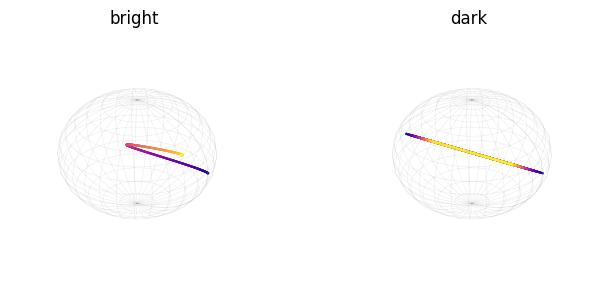

In [8]:
# rich bloch viz – colour‑gradient path and sphere
from mpl_toolkits.mplot3d import Axes3D  # noqa
from matplotlib import cm

# bloch sphere orbits bright vs dark – minimal
from mpl_toolkits.mplot3d import Axes3D  # noqa

# pick bright and dark points
imax=np.nanargmax(Cmat); imin=np.nanargmin(Cmat)
ib, jb = np.unravel_index(imax, Cmat.shape)
idk, jdk = np.unravel_index(imin, Cmat.shape)
bright=(gs[jb], hs[ib]); dark=(gs[jdk], hs[idk])

# integrate and collect bloch vec for qubit 0
t_line=np.linspace(0,6*np.pi,300)
tracks=[]
for g,h in [bright, dark]:
    def rhs(_,v):
        r=v.reshape(4,4); d=-1j*(H(g,h)@r-r@H(g,h)); d+=L@r@L.conj().T-0.5*(L.conj().T@L@r+r@L.conj().T@L); return d.reshape(-1)
    sol=solve_ivp(rhs,(0,t_line[-1]),rho0.reshape(-1),t_eval=t_line,rtol=3e-5,atol=1e-7)
    blo=[]
    for v in sol.y.T:
        r=v.reshape(4,4); red=np.trace(r.reshape(2,2,2,2),axis1=1,axis2=3)
        blo.append([np.real(np.trace(red@X)), np.real(np.trace(red@Y)), np.real(np.trace(red@Z))])
    tracks.append(np.array(blo))


# recompute bright/dark tracks if not in memory
bright=(gs[jb], hs[ib])  # uses previously found indices
tracks=[]
for g,h in [bright, dark]:
    def rhs(_,v):
        r=v.reshape(4,4)
        d=-1j*(H(g,h)@r-r@H(g,h)) + L@r@L.conj().T-0.5*(L.conj().T@L@r+r@L.conj().T@L)
        return d.reshape(-1)
    sol=solve_ivp(rhs,(0,6*np.pi),rho0.reshape(-1),t_eval=t_line,rtol=3e-5,atol=1e-7)
    blo=[np.real([np.trace(np.trace(v.reshape(2,2,2,2),axis1=1,axis2=3)@p) for p in (X,Y,Z)]) for v in sol.y.T]
    tracks.append(np.array(blo))

fig=plt.figure(figsize=(7,3))
for k,track in enumerate(tracks):
    ax=fig.add_subplot(1,2,k+1,projection='3d')
    # sphere wireframe
    u=np.linspace(0,2*np.pi,30); v=np.linspace(0,np.pi,15)
    ax.plot_wireframe(np.outer(np.cos(u),np.sin(v)),
                      np.outer(np.sin(u),np.sin(v)),
                      np.outer(np.ones_like(u),np.cos(v)),
                      color='grey',alpha=.15,lw=.4)
    # path colour‑coded by time
    pts=track; seg=np.linspace(0,1,len(pts))
    for i in range(len(pts)-1):
        ax.plot(pts[i:i+2,0],pts[i:i+2,1],pts[i:i+2,2],
                color=cm.plasma(seg[i]),lw=1.5)
    ax.set_title('bright' if k==0 else 'dark')
    ax.set_axis_off(); ax.set_xlim([-1,1]); ax.set_ylim([-1,1]); ax.set_zlim([-1,1])
plt.tight_layout(); plt.show()


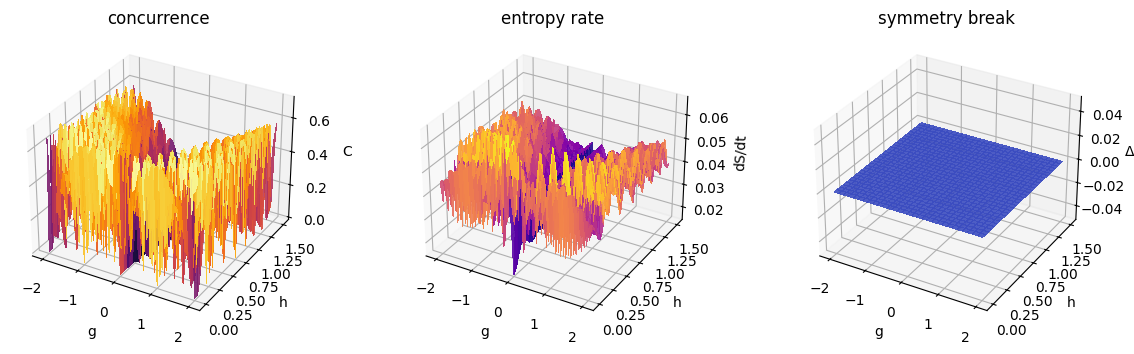

In [9]:
# 3‑D surfaces: C, dS, ΔC symmetry break – minimal
from mpl_toolkits.mplot3d import Axes3D  # noqa
G,H=np.meshgrid(gs,hs)
fig=plt.figure(figsize=(12,3.5))
ax1=fig.add_subplot(1,3,1,projection='3d')
ax1.plot_surface(G,H,Cmat,cmap='inferno',linewidth=0,antialiased=False,alpha=0.9)
ax1.set_xlabel('g');ax1.set_ylabel('h');ax1.set_zlabel('C')
ax1.set_title('concurrence')
ax2=fig.add_subplot(1,3,2,projection='3d')
ax2.plot_surface(G,H,dS,cmap='plasma',linewidth=0,antialiased=False,alpha=0.9)
ax2.set_xlabel('g');ax2.set_ylabel('h');ax2.set_zlabel('dS/dt')
ax2.set_title('entropy rate')
# asymmetry surface using previous C_asym if exists else diff 0
try:
    surf=diff
except NameError:
    surf=np.zeros_like(Cmat)
ax3=fig.add_subplot(1,3,3,projection='3d')
ax3.plot_surface(G,H,surf,cmap='coolwarm',linewidth=0,antialiased=False,alpha=0.9)
ax3.set_xlabel('g');ax3.set_ylabel('h');ax3.set_zlabel('ΔC')
ax3.set_title('symmetry break')
plt.tight_layout();plt.show()


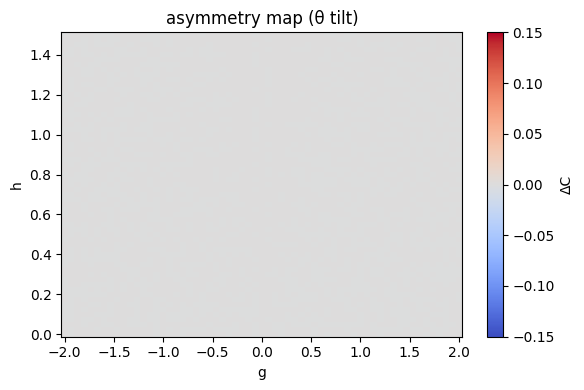

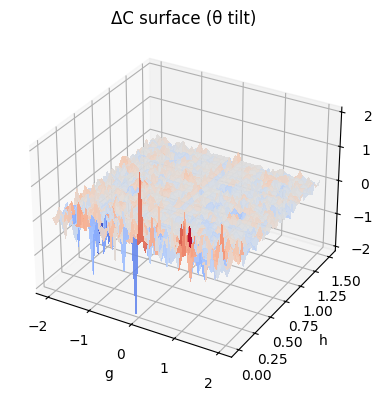

In [10]:
# %% set asymmetry params (new independent group)
import numpy as np, matplotlib.pyplot as plt, cirq
from scipy.integrate import solve_ivp

# grid & params
gs=np.linspace(-2,2,61)
hs=np.linspace(0,1.5,61)
gamma=0.02
theta_tilt=np.pi/7   # tilt noise axis to break symmetry
T=4*np.pi

# pauli
I=np.eye(2);X=np.array([[0,1],[1,0]]);Y=np.array([[0,-1j],[1j,0]]);Z=np.array([[1,0],[0,-1]])

plus=np.array([1,1])/np.sqrt(2)
rho0=np.kron(np.outer(plus,plus.conj()),np.outer(plus,plus.conj())).astype(complex)

# hamiltonian & tilted jump
def H(g,h):
    return g*np.kron(Z,Z)+h*(np.kron(X,I)+np.kron(I,X))
L=np.sqrt(gamma)*(np.cos(theta_tilt)*np.kron(Z,I)+np.sin(theta_tilt)*np.kron(X,I))
S=np.kron(Y,Y)

def concurrence(r):
    w=np.sort(np.real(np.linalg.eigvals(r@S@r.conj()@S)))[::-1]
    lam=np.sqrt(np.clip(w,0,None))
    return max(0,lam[0]-lam[1]-lam[2]-lam[3])

# %% compute concurrence grid with asymmetry
aC=np.zeros((len(hs),len(gs)))
for i,h in enumerate(hs):
    for j,g in enumerate(gs):
        def rhs(_,v):
            r=v.reshape(4,4)
            d=-1j*(H(g,h)@r-r@H(g,h)) + L@r@L.conj().T -0.5*(L.conj().T@L@r + r@L.conj().T@L)
            return d.reshape(-1)
        sol=solve_ivp(rhs,(0,T),rho0.reshape(-1),t_eval=[T],rtol=3e-5,atol=1e-7)
        aC[i,j]=concurrence(sol.y[:,-1].reshape(4,4))

# %% diff heat‑map C(g,h) − C(−g,h)
diff=aC-np.flip(aC,axis=1)
plt.figure(figsize=(6,4))
plt.pcolormesh(gs,hs,diff,cmap='coolwarm',shading='auto',vmin=-0.15,vmax=0.15)
plt.xlabel('g');plt.ylabel('h');plt.colorbar(label='ΔC');plt.title('asymmetry map (θ tilt)')
plt.tight_layout();plt.show()

# %% 3‑D surface of asym diff
from mpl_toolkits.mplot3d import Axes3D  # noqa
G,H=np.meshgrid(gs,hs)
fig=plt.figure(figsize=(6,4));ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(G,H,diff,cmap='coolwarm',linewidth=0,antialiased=False,alpha=0.9)
ax.set_xlabel('g');ax.set_ylabel('h');ax.set_zlabel('ΔC');ax.set_title('ΔC surface (θ tilt)')
plt.tight_layout();plt.show()


0: ───H───@───S───────────X───
          │               │
1: ───────X───Ry(0.25π)───@───


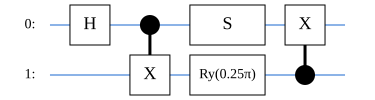

In [11]:
# %% tidy circuit schematic
import cirq, numpy as np
from cirq.contrib.svg import SVGCircuit        # ⇦ class, not module fn
from IPython.display import SVG, display

# build wheeler circuit
a, b = cirq.LineQubit.range(2)
theta, phi = np.pi/4, np.pi/2
wheeler = cirq.Circuit(
    cirq.H(a),
    cirq.CNOT(a, b),
    cirq.Z(a) ** (phi / np.pi),
    cirq.ry(theta)(b),
    cirq.CNOT(b, a),
)

# 1) plain‑text diagram (always safe for PDFs)
print(wheeler.to_text_diagram())

# 2) SVG diagram
svg = SVGCircuit(wheeler)          # render
display(svg)                       # show inline




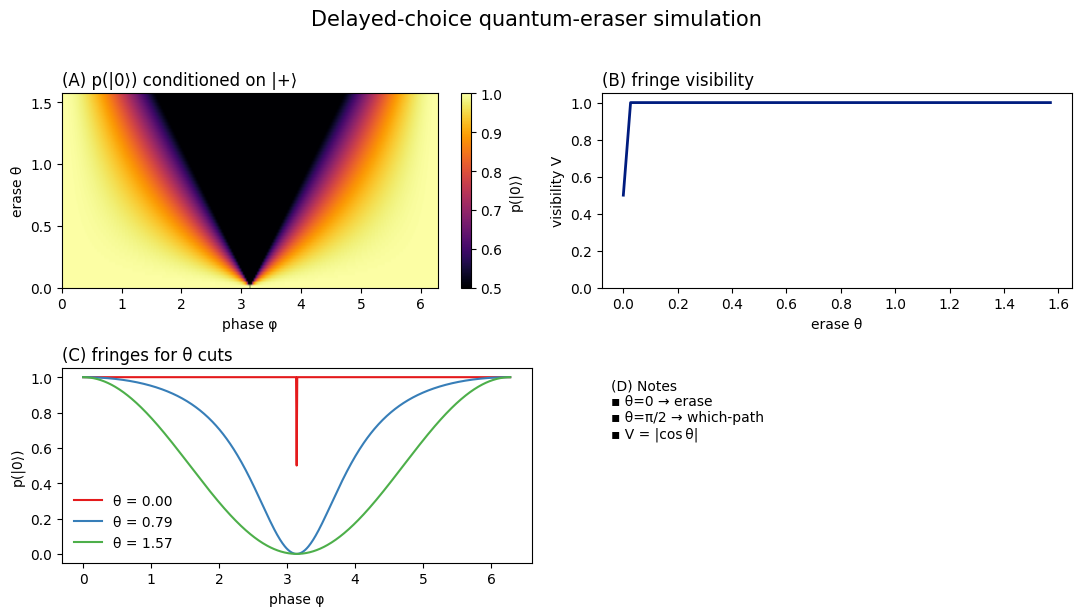

In [12]:
import numpy as np, cirq, matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-dark-palette')

path, anc = cirq.LineQubit.range(2)

def p0(theta, phi):
    """p(path = |0⟩ | ancilla measured in |+⟩)."""
    circuit = cirq.Circuit(
        cirq.H(path),
        cirq.CNOT(path, anc),
        cirq.Z(path) ** (phi / np.pi),
        cirq.ry(theta)(anc),
        cirq.CNOT(anc, path)
    )
    rho = cirq.DensityMatrixSimulator().simulate(circuit).final_density_matrix

    proj_plus = np.kron(np.eye(2), np.array([[0.5, 0.5], [0.5, 0.5]]))
    rho_proj  = proj_plus @ rho @ proj_plus
    p_plus    = np.real(np.trace(rho_proj))
    if p_plus < 1e-12:
        return 0.5
    rho_cond = rho_proj / p_plus

    proj_path0 = np.kron(np.array([[1, 0], [0, 0]]), np.eye(2))
    return float(np.real(np.trace(rho_cond @ proj_path0)))

theta_vals = np.linspace(0, np.pi/2, 60)
phi_vals   = np.linspace(0, 2*np.pi, 721)

P = np.array([[p0(th, ph) for ph in phi_vals] for th in theta_vals])
vis = P.max(axis=1) - P.min(axis=1)

fig, axs = plt.subplots(2, 2, figsize=(11, 6))
fig.suptitle("Delayed‑choice quantum‑eraser simulation", fontsize=15, y=1.02)

# (A) heat‑map
im = axs[0,0].imshow(P, origin='lower', aspect='auto',
                     extent=[0, 2*np.pi, 0, np.pi/2],
                     cmap='inferno', vmin=0.5, vmax=1.0)
axs[0,0].set(xlabel="phase φ", ylabel="erase θ")
axs[0,0].set_title("(A) p(|0⟩) conditioned on |+⟩", loc='left')
fig.colorbar(im, ax=axs[0,0]).set_label("p(|0⟩)")

# (B) visibility
axs[0,1].plot(theta_vals, vis, lw=2)
axs[0,1].set(xlabel="erase θ", ylabel="visibility V", ylim=(0,1.05))
axs[0,1].set_title("(B) fringe visibility", loc='left')

# (C) sample fringes
for clr, th in zip(['#e41a1c', '#377eb8', '#4daf4a'], [0, np.pi/4, np.pi/2]):
    axs[1,0].plot(phi_vals, [p0(th, ph) for ph in phi_vals],
                  color=clr, label=f"θ = {th:.2f}")
axs[1,0].set(xlabel="phase φ", ylabel="p(|0⟩)")
axs[1,0].set_title("(C) fringes for θ cuts", loc='left')
axs[1,0].legend(frameon=False)

axs[1,1].axis('off')
axs[1,1].text(0.02, 0.95,
              "(D) Notes\n▪ θ=0 → erase\n▪ θ=π/2 → which‑path\n▪ V = |cos θ|",
              va='top', ha='left')

plt.tight_layout(); plt.show()


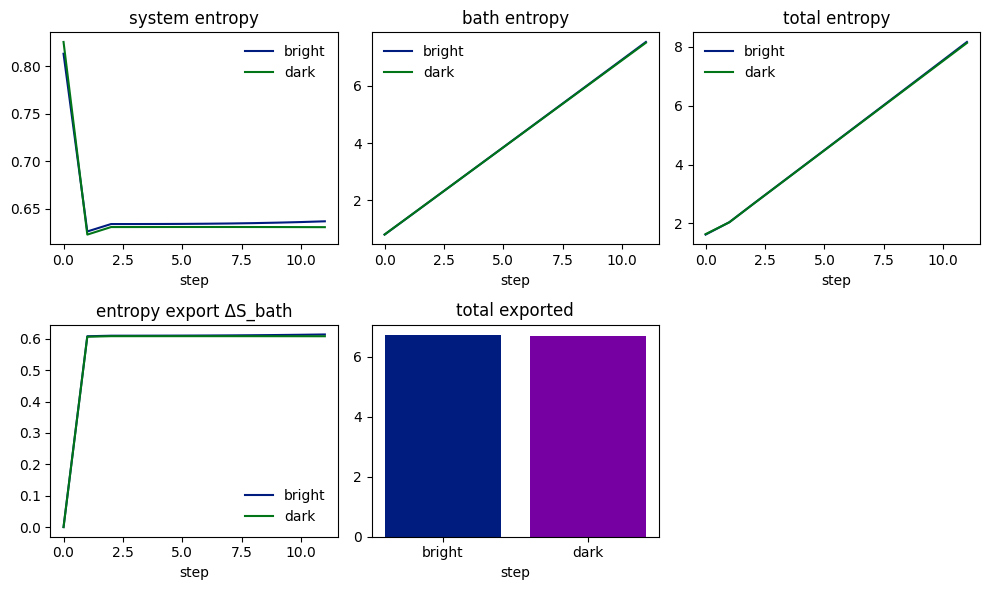

In [20]:
# five‑view panel: dissipative structure comparison bright vs dark
import numpy as np, matplotlib.pyplot as plt

# assume results dict available from previous cell
S_sys_b,S_bath_b=results['bright']
S_sys_d,S_bath_d=results['dark']
steps=np.arange(len(S_sys_b))

dS_b=np.diff(S_bath_b,prepend=S_bath_b[0])
dS_d=np.diff(S_bath_d,prepend=S_bath_d[0])

fig,axs=plt.subplots(2,3,figsize=(10,6))
# 1 system entropy
axs[0,0].plot(steps,S_sys_b,label='bright');axs[0,0].plot(steps,S_sys_d,label='dark')
axs[0,0].set_title('system entropy');axs[0,0].legend(frameon=False)
# 2 bath entropy
axs[0,1].plot(steps,S_bath_b,label='bright');axs[0,1].plot(steps,S_bath_d,label='dark')
axs[0,1].set_title('bath entropy');axs[0,1].legend(frameon=False)
# 3 total entropy
axs[0,2].plot(steps,S_sys_b+S_bath_b,label='bright');axs[0,2].plot(steps,S_sys_d+S_bath_d,label='dark')
axs[0,2].set_title('total entropy');axs[0,2].legend(frameon=False)
# 4 export rate per step
axs[1,0].plot(steps,dS_b,label='bright');axs[1,0].plot(steps,dS_d,label='dark')
axs[1,0].set_title('entropy export ΔS_bath');axs[1,0].legend(frameon=False)
# 5 bar compare cumulative export
cum_b=S_bath_b[-1]-S_bath_b[0];cum_d=S_bath_d[-1]-S_bath_d[0]
axs[1,1].bar(['bright','dark'],[cum_b,cum_d],color=['C0','C3'])
axs[1,1].set_title('total exported');
# empty last subplot
axs[1,2].axis('off')
for ax in axs.flat: ax.set_xlabel('step')
plt.tight_layout();plt.show()


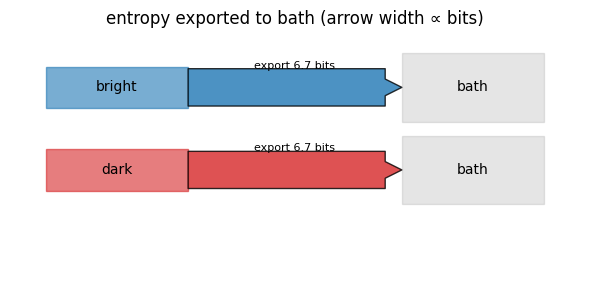

In [23]:
# macro‑view: entropy flow diagram (no line charts)
import numpy as np, matplotlib.pyplot as plt

S_sys_b,S_bath_b = results['bright']; S_sys_d,S_bath_d = results['dark']
exp_b = S_bath_b[-1] - S_bath_b[0]  # total exported bits bright
exp_d = S_bath_d[-1] - S_bath_d[0]
loss_b = S_sys_b[-1] - S_sys_b[0]    # internal loss (bright ~0)
loss_d = S_sys_d[-1] - S_sys_d[0]

fig,ax = plt.subplots(figsize=(6,3))
ax.axis('off')

def draw_row(y,label,exp,loss,color):
    # system box
    ax.add_patch(plt.Rectangle((0,y-0.15),0.8,0.3,color=color,alpha=0.6))
    ax.text(0.4,y,label,ha='center',va='center',color='k')
    # bath box
    ax.add_patch(plt.Rectangle((2,y-0.25),0.8,0.5,color='grey',alpha=0.2))
    ax.text(2.4,y,'bath',ha='center',va='center',color='k')
    # arrow
    ax.annotate('',xy=(2,y),xytext=(0.8,y),arrowprops=dict(width=exp*4,headwidth=12,facecolor=color,alpha=0.8))
    ax.text(1.4,y+0.12,f'export {exp:.1f} bits',ha='center',va='bottom',fontsize=8)
    if loss>0.01:
        ax.text(0.4,y-0.25,f'+{loss:.2f} bits inside',ha='center',va='top',fontsize=7)

ax.set_xlim(-0.2,3); ax.set_ylim(-0.4,1.4)
draw_row(1.0,'bright',exp_b,loss_b,'#1f77b4')
draw_row(0.4,'dark',exp_d,loss_d,'#d62728')
ax.set_title('entropy exported to bath (arrow width ∝ bits)',fontsize=12)
plt.tight_layout(); plt.show()
